# Exploratory Data Analysis
Analisis eksploratif terhadap `aligned_dataset.csv` (nilai tukar USD/IDR harian +
gabungan berita harian) sebelum membangun ekstraksi fitur NLP dan model baseline.


## 1. Environment Setup & Raw Text Tools

In [46]:
%pip install nltk seaborn

Note: you may need to restart the kernel to use updated packages.


In [47]:
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Only basic stopwords for raw term analysis
nltk.download("stopwords", quiet=True)
print("Libraries loaded for raw EDA.")

Libraries loaded for raw EDA.


## Data Loading, Datetime Parsing, & Temporal Integrity

In [48]:
csv_path = "../data/processed/aligned_dataset.csv"  # Ganti sesuai path file Anda

df = pd.read_csv(csv_path)

# Enforce datetime formatting and sort chronologically
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(by="date").reset_index(drop=True)

# Check continuity and date range
date_range = pd.date_range(start=df["date"].min(), end=df["date"].max())
missing_calendar_days = date_range.difference(df["date"])

print(f"Date range               : {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Total rows               : {len(df)}")
print(f"Calendar days covered    : {len(date_range)}")
print(f"Gap / Non-trading days   : {len(missing_calendar_days)} days")
print("-" * 50)
df.info()
df.head(3)

Date range               : 2021-09-01 to 2026-09-01
Total rows               : 1202
Calendar days covered    : 1827
Gap / Non-trading days   : 625 days
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1202 entries, 0 to 1201
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     1202 non-null   datetime64[ns]
 1   usd_idr                  1202 non-null   int64         
 2   jumlah_berita            1202 non-null   int64         
 3   judul_gabungan           1185 non-null   object        
 4   lead_paragraph_gabungan  1185 non-null   object        
 5   konten_gabungan          1185 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 56.5+ KB


,date,usd_idr,jumlah_berita,judul_gabungan,lead_paragraph_gabungan,konten_gabungan
0,2021-09-01,14284,5,"I’ve paid off almost $200,000 of student loans in 3 years: Here's my best ad...","In 2015, I graduated law school with six figures of student loan debt. Since...","In 2015, I graduated law school with six figures of student loan debt. Since..."
1,2021-09-02,14281,5,Supreme Court refuses to block Texas law that bans most abortions | If you c...,The Supreme Court declined to block a Texas law banning most abortions in a ...,The Supreme Court declined to block a Texas law banning most abortions in a ...
2,2021-09-03,14261,4,"Jobs report disappoints — only 235,000 positions added vs. expectations of 7...","Job creation for August was a huge disappointment, with the economy adding j...","Job creation for August was a huge disappointment, with the economy adding j..."


## Data Hygiene & Missing Values

In [49]:
print("Missing values per column:")
print(df.isnull().sum())
print("-" * 50)

# Check for duplicate dates
dup_dates = df["date"].duplicated().sum()
print(f"Duplicate dates found: {dup_dates}")
print("-" * 50)

# Inspect days without news text
empty_days = df[df["judul_gabungan"].isna() | (df["judul_gabungan"] == "")]
print(f"Trading days without news: {len(empty_days)}")
print(f"Unique 'jumlah_berita' values on empty days: {empty_days['jumlah_berita'].unique()}")

Missing values per column:
date                        0
usd_idr                     0
jumlah_berita               0
judul_gabungan             17
lead_paragraph_gabungan    17
konten_gabungan            17
dtype: int64
--------------------------------------------------
Duplicate dates found: 0
--------------------------------------------------
Trading days without news: 17
Unique 'jumlah_berita' values on empty days: [0]


In [50]:
# Compute lengths across all 3 text columns
df["title_char_len"] = df["judul_gabungan"].fillna("").astype(str).apply(len)
df["title_word_count"] = df["judul_gabungan"].fillna("").apply(lambda x: len(x.split()))

df["lead_char_len"] = df["lead_paragraph_gabungan"].fillna("").astype(str).apply(len)
df["lead_word_count"] = df["lead_paragraph_gabungan"].fillna("").apply(lambda x: len(x.split()))

df["content_char_len"] = df["konten_gabungan"].fillna("").astype(str).apply(len)
df["content_word_count"] = df["konten_gabungan"].fillna("").apply(lambda x: len(x.split()))

# Include lead_word_count in describe()
raw_stats = df[[
    "usd_idr",
    "jumlah_berita",
    "title_word_count",
    "lead_word_count",
    "content_word_count"
]].describe().T

raw_stats

,count,mean,std,min,25%,50%,75%,max
usd_idr,1202.0,15741.955907,976.127715,14080.0,14984.00,15650.5,16384.75,18171.0
jumlah_berita,1202.0,11.989185,8.148950,0.0,8.00,11.0,14.00,100.0
title_word_count,1202.0,171.835275,120.110418,0.0,109.00,151.0,204.00,1490.0
lead_word_count,1202.0,875.994176,640.001601,0.0,531.00,728.5,1009.75,2999.0
content_word_count,1202.0,8424.997504,5864.307710,0.0,5177.25,7424.0,10198.75,71278.0


## Visualizing Text Length Distributions

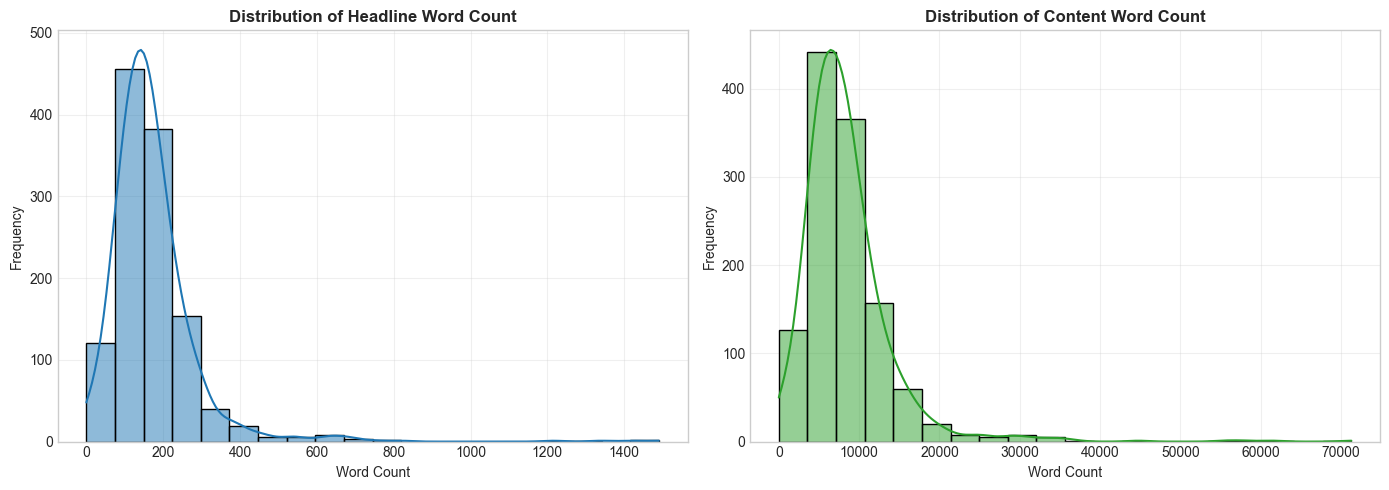

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of word counts: Titles vs Contents
sns.histplot(df["title_word_count"], kde=True, ax=axes[0], color="#1f77b4", bins=20)
axes[0].set_title("Distribution of Headline Word Count", fontweight="bold")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")

sns.histplot(df["content_word_count"], kde=True, ax=axes[1], color="#2ca02c", bins=20)
axes[1].set_title("Distribution of Content Word Count", fontweight="bold")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Visualizing Raw Time-Series Trends

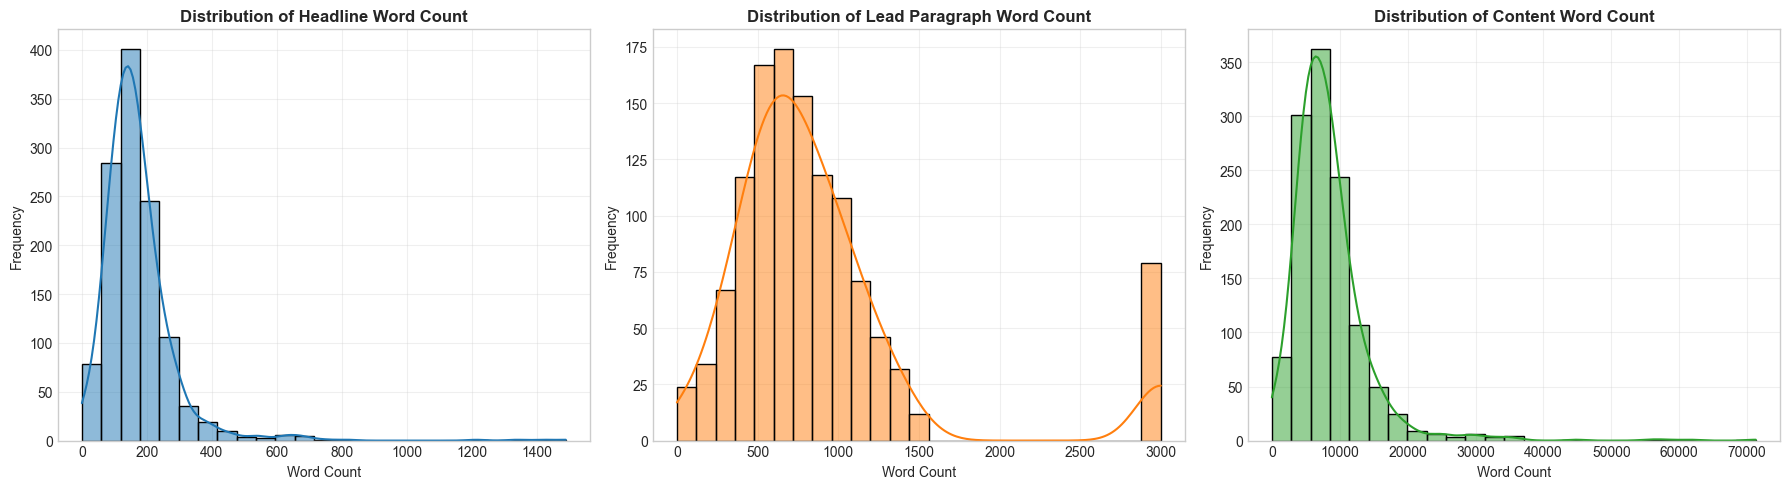

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution of Headline Word Count
sns.histplot(df["title_word_count"], kde=True, ax=axes[0], color="#1f77b4", bins=25)
axes[0].set_title("Distribution of Headline Word Count", fontweight="bold")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")

# 2. Distribution of Lead Paragraph Word Count
sns.histplot(df["lead_word_count"], kde=True, ax=axes[1], color="#ff7f0e", bins=25)
axes[1].set_title("Distribution of Lead Paragraph Word Count", fontweight="bold")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")

# 3. Distribution of Full Content Word Count
sns.histplot(df["content_word_count"], kde=True, ax=axes[2], color="#2ca02c", bins=25)
axes[2].set_title("Distribution of Content Word Count", fontweight="bold")
axes[2].set_xlabel("Word Count")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Raw Vocabulary & Most Frequent Unigrams/Bigrams

C:\Users\Anders\AppData\Local\Temp\ipykernel_25728\3057395165.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="frequency", y="token", data=plot_df, palette="crest")


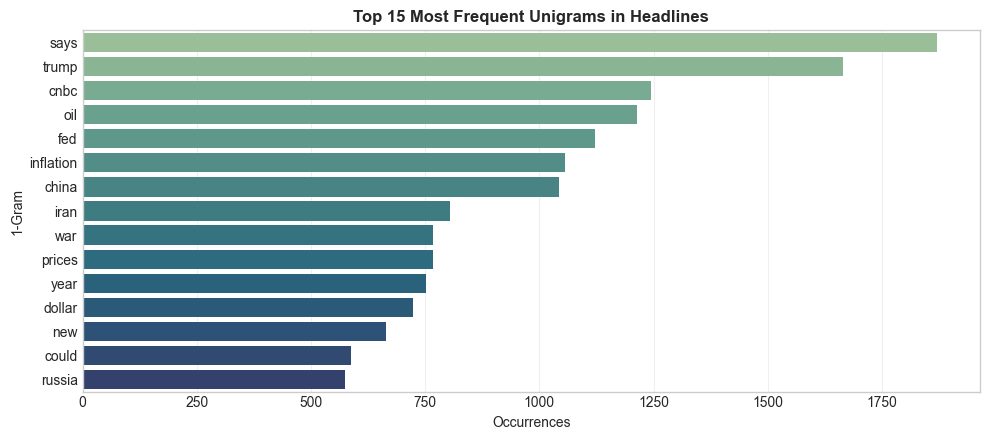

C:\Users\Anders\AppData\Local\Temp\ipykernel_25728\3057395165.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="frequency", y="token", data=plot_df, palette="crest")


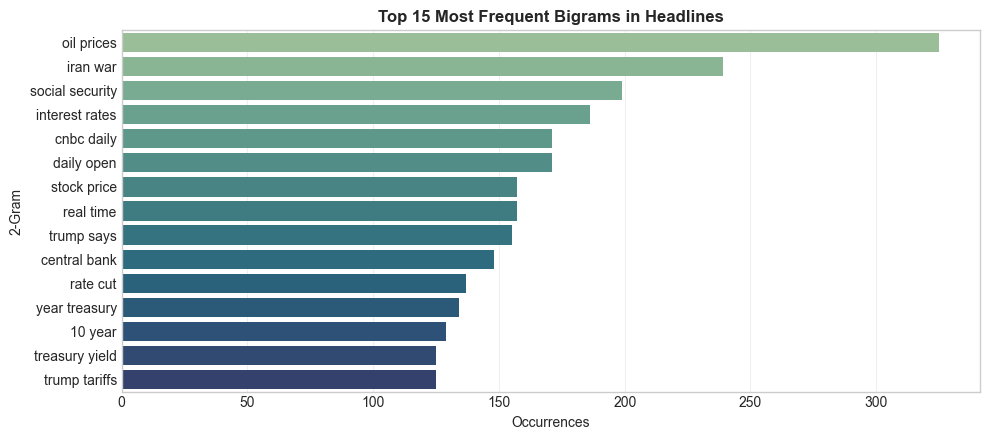

In [53]:
stop_words = list(stopwords.words("english"))

def plot_top_ngrams(text_series, title, n=1, top_k=15):
    # Remove the '|' delimiter so it doesn't parse into tokens
    cleaned = text_series.fillna("").str.replace("|", " ", regex=False)
    
    vec = CountVectorizer(ngram_range=(n, n), stop_words=stop_words, min_df=1)
    bow = vec.fit_transform(cleaned)
    counts = bow.sum(axis=0)
    
    freq = [(word, counts[0, idx]) for word, idx in vec.vocabulary_.items()]
    freq = sorted(freq, key=lambda x: x[1], reverse=True)[:top_k]
    
    plot_df = pd.DataFrame(freq, columns=["token", "frequency"])
    
    plt.figure(figsize=(10, 4.5))
    sns.barplot(x="frequency", y="token", data=plot_df, palette="crest")
    plt.title(title, fontweight="bold")
    plt.xlabel("Occurrences")
    plt.ylabel(f"{n}-Gram")
    plt.tight_layout()
    plt.show()

# Inspect top unigrams and bigrams directly from raw headlines
plot_top_ngrams(df["judul_gabungan"], "Top 15 Most Frequent Unigrams in Headlines", n=1)
plot_top_ngrams(df["judul_gabungan"], "Top 15 Most Frequent Bigrams in Headlines", n=2)